# <font color='black'>Регрессионный анализ: панельные данные и каузальность, 2026 </font>
## <font color='black'> Практическое занятие 5. Модели со смешанными эффектами применительно к вложенным кросс-секционным данным </font>
Рассмотрим пример оценивания моделей со смешанными эффектами на кросс-секционных данных из статьи [Luke D.A., Krauss M., 2004] (статью можете скачать по ссылке https://yadi.sk/i/w_dgDbu8blukXA). Авторы изучают факторы голосования членов Конгресса США в интересах табачной индустрии. В фокусе внимания - различия во взаимосвязи размера финансирования комитетами политического действия (PAC) от табачных корпораций и голосования в интересах табачной индустрии. В частности, авторы тестируют, есть ли различия в этой взаимосвязи между представителями Демократической и Республиканской партий.

### Краткое описание данных:
* state - штат (группирующая переменная)
* lastname - член Конгресса
#### Переменные на первом уровне:
* votepct - доля голосов, отданных членом Конгресса в поддержку табачной индустрии (зависимая переменная)
* party - дамми-переменная: представитель Демократической или Республиканской партии (0 - Демократы, 1 - Республиканцы)
* money - размер финансирования от PAC табачных корпораций (в 10,000$)
#### Предиктор на втором уровне:
* acres - площадь табачных плантаций (10,000 акров)

Подгрузим необходимые библиотеки и откроем массив "MEmodels.dta".

In [ ]:
import pandas as pd
import numpy as np
import math
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLMParams

In [ ]:
mixed = pd.read_stata('MEmodels.dta')
mixed = mixed.dropna()
mixed.head(10)

,house,state,sid,lastname,votepct,party,money,acres
0,Senate,AK,AK,Murkowski,0.842105,Republican,9.166,0.0
1,Senate,AK,AK,Stevens,0.846154,Republican,0.000,0.0
2,House,AK,AK,Young,0.571429,Republican,23.500,0.0
3,Senate,AL,AL,Shelby,0.641026,Republican,24.166,0.0
4,House,AL,AL,Aderholt,0.900000,Republican,35.000,0.0
5,House,AL,AL,Bachus,0.666667,Republican,3.000,0.0
6,House,AL,AL,Callahan,0.777778,Republican,5.500,0.0
7,House,AL,AL,Cramer,0.888889,Democrat,14.050,0.0
8,House,AL,AL,Everett,1.000000,Republican,6.000,0.0
9,House,AL,AL,Hilliard,0.600000,Democrat,31.000,0.0


Представим описательные статистики:

In [ ]:
mixed.describe()

,votepct,money,acres
count,524.000000,524.000000,524.000000
mean,0.517454,13.040197,14.358092
std,0.347941,18.456481,41.602969
min,0.000000,0.000000,0.000000
25%,0.200000,0.000000,0.000000
50%,0.592169,4.500000,0.000000
75%,0.843117,20.525000,6.500000
max,1.000000,113.100000,221.650000


По описательным статистикам видно, что распределения для переменных money и acres являются скошенными вправо. Кроме того, для довольно большой части наблюдений переменные принимают значение 0. Проиллюстрируем это так же на графиках, построив гистрограммы для этих переменных:

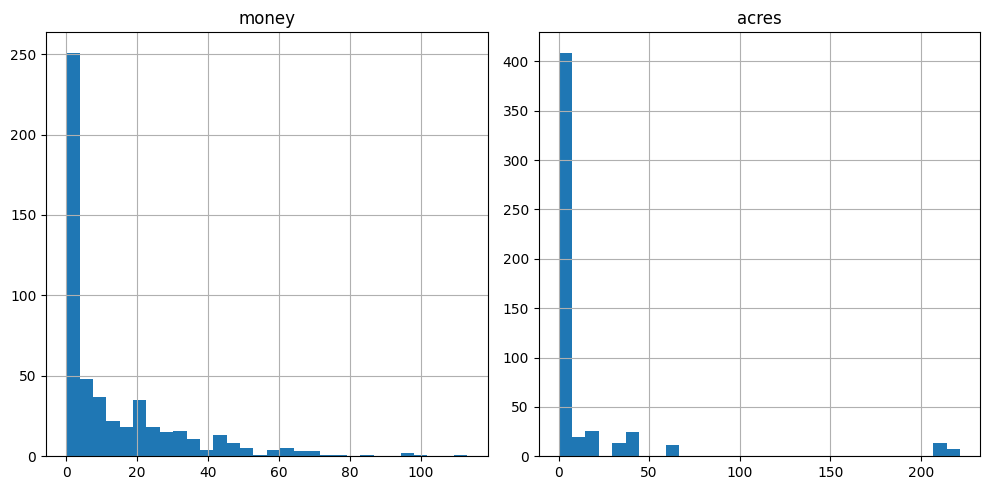

In [ ]:
mixed[['money', 'acres']].hist(bins=30, figsize=(10, 5), layout=(1, 2))
plt.tight_layout()
plt.show()

Перед оцениванием моделей преобразуем предикторы money и acres посредством взятия натурального логарифма. Так как в распределениях присутствуют нули, прибавим предварительно к исходным значениям переменных константу (+1)

In [ ]:
mixed['money_log'] = np.log(mixed['money'] + 1)
mixed['acres_log'] = np.log(mixed['acres'] + 1)

Для начала оценим модель ANOVA (то есть, модель без предикторов). Запишите ее спецификацию (m0) в терминах модели со смешанными эффектами (в том числе, не только в общем виде, но и подставив полученные оценки). Вспомните, зачем нужна такая модель без предикторов в начале исследования

При оценивании используем классический метод максимального правдоподобия (выборка на втором уровне составляет 50) вместо restricted MLE. Для выбора классического метода максимального правдоподобия после .fit пропишем reml = False

In [ ]:
m0 = smf.mixedlm("votepct ~ 1", groups="state", data=mixed).fit(reml = False)
print(m0.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: votepct  
No. Observations: 524     Method:             ML       
No. Groups:       50      Scale:              0.0931   
Min. group size:  2       Log-Likelihood:     -157.0369
Max. group size:  55      Converged:          Yes      
Mean group size:  10.5                                 
-------------------------------------------------------
              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.530    0.031 17.097 0.000  0.469  0.591
state Var     0.035    0.034                           



На основе оценок данной модели рассчитаем значение ICC. В выдаче scale - дисперсия ошибок на индивидуальном уровне (то есть, внутригрупповая дисперсия)

Проинтерпретируйте полученное значение ICC

In [ ]:
ICC = m0.cov_re/(m0.cov_re + m0.scale)
ICC

,state
state,0.271911


Для определения значимости полученных оценок в модели выведем значения p-value

1) Для проверки значимости параметров для фиксированных эффектов используется тест Вальда, так как в модели со смешанными эффектами неоднозначно определение количества степеней свободы для t-статистики

$$W = \dfrac{\beta^2}{Var(\beta)} \sim \chi^2(df = 1)$$

2) Полученное значение p-value для дисперсии случайного эффекта (state Var) кажется неинтуитивным с учетом того, что оценка дисперсии в выдаче выше получилась $\approx 0.035$, а соответствующая стандартная ошибка близка к значению оценки дисперсии ($\approx 0.034$). Но не будем забывать, что мы проверяем значимость дисперсии, а не коэффициента в регрессии для фиксированного эффекта. Для проверки значимости дисперсии случайного эффекта используется уже знакомый Вам тест отношения правдоподобия

Для этого сравниваются две модели:

m_short - модель более экономная, без соответствующего случайного эффекта

m_long - модель с включенным случайным эффектом

$$LR = 2ln(\dfrac{L(m\_long)}{L(m\_short)}) \sim \chi^2(df = 1)$$

Считаем p-value по наблюдаемому значению статистики, этот p-value будет свидетельствовать о том, значима ли дисперсия для соответствующего случайного эффекта

In [ ]:
m0.pvalues.round(5)

,0
Intercept,0.00000
state Var,0.00075


Обратите внимание на то, что в оценках модели выводится именно дисперсия случайного эффекта. Для того, чтобы посмотреть отклонения константы ("стартового" значения зависимой переменной) в том или ином штате от среднего по всей выборке, получим значения BLUP (best linear unbiased prediction):

In [ ]:
random_effects = m0.random_effects

df_random = pd.DataFrame(
    [(state, re.iloc[0]) for state, re in random_effects.items()],
    columns=['State', 'BLUP']
)

df_random = df_random.sort_values('BLUP', ascending=True)

print(df_random.to_string(index=False))

State      BLUP
   MA -0.404359
   CT -0.274718
   RI -0.246578
   ND -0.200293
   HI -0.190974
   NJ -0.179272
   NY -0.170188
   MD -0.167409
   ME -0.153554
   NV -0.152018
   OR -0.150158
   SD -0.134207
   VT -0.133449
   WV -0.127228
   WA -0.122535
   MN -0.117482
   WI -0.113412
   MI -0.112218
   DE -0.085627
   CA -0.083409
   PA -0.057922
   OH -0.038649
   IL -0.037222
   IA -0.010264
   NM  0.013976
   MT  0.018747
   FL  0.037440
   UT  0.038496
   TX  0.067744
   AR  0.077079
   NE  0.085147
   CO  0.089711
   MO  0.096847
   AZ  0.114168
   AK  0.117918
   IN  0.121912
   VA  0.129155
   KS  0.132178
   MS  0.133808
   NH  0.145187
   LA  0.145809
   GA  0.150235
   TN  0.157290
   ID  0.176953
   SC  0.189117
   WY  0.193283
   AL  0.209208
   NC  0.253381
   OK  0.264744
   KY  0.303614


Добавим в массив еще стандартные ошибки BLUP для последующей проверки значимости отклонений от общего среднего:  

In [ ]:
cov = m0.random_effects_cov

df_random['BLUP_SE'] = df_random['State'].apply(
    lambda state: np.sqrt(cov[state].iloc[0, 0])
)

print(df_random.to_string(index=False))

State      BLUP  BLUP_SE
   MA -0.404359 0.082515
   CT -0.274718 0.093390
   RI -0.246578 0.118093
   ND -0.200293 0.128072
   HI -0.190974 0.118093
   NJ -0.179272 0.072581
   NY -0.170188 0.051822
   MD -0.167409 0.085707
   ME -0.153554 0.118093
   NV -0.152018 0.118093
   OR -0.150158 0.098096
   SD -0.134207 0.128072
   VT -0.133449 0.141099
   WV -0.127228 0.110134
   WA -0.122535 0.082515
   MN -0.117482 0.085707
   WI -0.113412 0.082515
   MI -0.112218 0.067110
   DE -0.085627 0.128072
   CA -0.083409 0.040182
   PA -0.057922 0.060223
   OH -0.038649 0.064082
   IL -0.037222 0.062715
   IA -0.010264 0.098096
   NM  0.013976 0.110134
   MT  0.018747 0.128072
   FL  0.037440 0.058006
   UT  0.038496 0.110134
   TX  0.067744 0.051822
   AR  0.077079 0.110134
   NE  0.085147 0.110134
   CO  0.089711 0.098096
   MO  0.096847 0.082515
   AZ  0.114168 0.093390
   AK  0.117918 0.128072
   IN  0.121912 0.082515
   VA  0.129155 0.079654
   KS  0.132178 0.103594
   MS  0.133808 0.098096


Выведем на графике BLUP для константы по штатам, дополнив их границами 95%-ых доверительных интервалов. Эти доверительные интервалы демонстрируют, что большинство отклонений от общего среднего, явлюятся незначимыми:

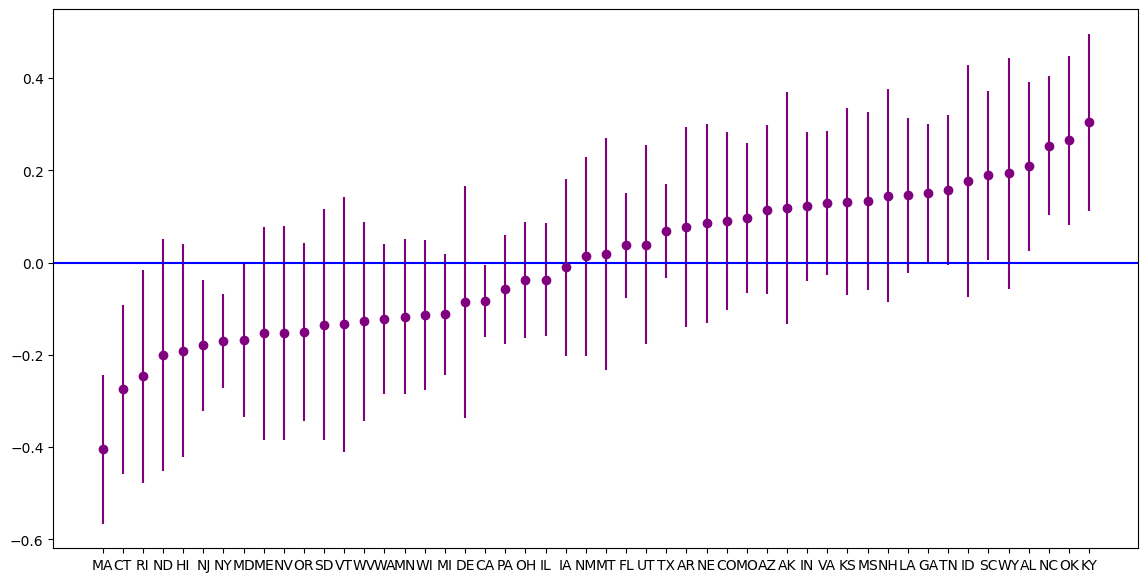

In [ ]:
plt.figure(figsize=(14, 7))

plt.errorbar(df_random.State, df_random.BLUP, yerr=stats.norm.ppf(0.975)*df_random.BLUP_SE,
             color ='purple', fmt='o')

plt.axhline(y=0, color ='b', linestyle = '-')

Поработаем над спецификацией модели, включив сначала только фиксированные эффекты на предикторы первого уровня - размер финансирования от PAC, а также показатель партийной принадлежности. То есть, оцениваем на данном этапе, какой в среднем характер связи по массиву в целом, пока не учитывая возможные различия во взаимосвязи по штатам

In [ ]:
m1 = smf.mixedlm("votepct ~ money_log + party", groups="state", data=mixed).fit(reml = False)
print(m1.summary())

            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   votepct 
No. Observations:    524       Method:               ML      
No. Groups:          50        Scale:                0.0278  
Min. group size:     2         Log-Likelihood:       170.3012
Max. group size:     55        Converged:            Yes     
Mean group size:     10.5                                    
-------------------------------------------------------------
                    Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           0.161    0.018  9.049 0.000  0.126  0.195
party[T.Republican] 0.475    0.016 29.462 0.000  0.443  0.506
money_log           0.065    0.006 10.848 0.000  0.053  0.076
state Var           0.006    0.012                           



/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


В модель m2 включим предиктор второго уровня - площадь табачных плантаций. Так как этот предиктор меняется только на уровне штатов (одно значение - для каждого штата, отсутствует внутригрупповая дисперсия), возможно включить только фиксированный эффект, то есть, оценить средний характер взаимосвязи по всему массиву в целом

In [ ]:
m2 = smf.mixedlm("votepct ~ acres_log", groups="state", data=mixed).fit(reml = False)
print(m2.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: votepct  
No. Observations: 524     Method:             ML       
No. Groups:       50      Scale:              0.0933   
Min. group size:  2       Log-Likelihood:     -151.9655
Max. group size:  55      Converged:          Yes      
Mean group size:  10.5                                 
-------------------------------------------------------
              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.461    0.034 13.443 0.000  0.394  0.529
acres_log     0.059    0.017  3.384 0.001  0.025  0.093
state Var     0.025    0.027                           



Сравним эти модели m1 и m2 при помощи информационных критериев

In [ ]:
print('AIC(m1):', m1.aic, 'BIC(m1):', m1.bic, '\n' 'AIC(m2)', m2.aic, 'BIC(m2):', m2.bic)

AIC(m1): -330.60238877338134 BIC(m1): -309.29493035177615 
AIC(m2) 311.93096784455383 BIC(m2): 328.976934581838


Как уже было отмечено, авторы тестировали различия во взаимосвязи голосования в поддержку табачной индустрии и финансирования от PAC в зависимости от партийной принадлежности. Модель m3 наиболее полная: включает предикторы первого и второго уровня, а также переменную взаимодействия - то есть, совместный эффект партийной принадлежности и голосования в поддержку табачной индустрии


In [ ]:
m3 = smf.mixedlm("votepct ~ money_log*party + acres_log", groups="state", data=mixed).fit(reml = False)
print(m3.summary())

                 Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       votepct 
No. Observations:       524           Method:                   ML      
No. Groups:             50            Scale:                    0.0263  
Min. group size:        2             Log-Likelihood:           186.8940
Max. group size:        55            Converged:                Yes     
Mean group size:        10.5                                            
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      0.102    0.020  5.237 0.000  0.064  0.140
party[T.Republican]            0.564    0.023 24.194 0.000  0.519  0.610
money_log                      0.092    0.008 11.213 0.000  0.076  0.109
money_log:party[T.Republican] -0.054    0.011 -5.161 0.000 -0.075 -0.

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [ ]:
m3.pvalues.round(5)

,0
Intercept,0.00000
party[T.Republican],0.00000
money_log,0.00000
money_log:party[T.Republican],0.00000
acres_log,0.01057
state Var,0.00903


Вложенные модели со смешанными эффектами сравниваются при помощи теста отношения правдоподобия. Для иллюстрации сравним m1 и m3:

In [ ]:
lr_stat = 2*(m3.llf - m1.llf)
lr_pvalue = stats.chi2.sf(lr_stat, df = len(m3.params) - len(m1.params))
print('Chi-squared:', lr_stat, '\n' 'P-value:', lr_pvalue)

Chi-squared: 33.1856846830965 
P-value: 6.220426057553223e-08


Учтем возможные различия в характере взаимосвязи предикторов на индивидуальном уровне и зависимой переменной. Для этого в модель m4 включен дополнительный случайный эффект. В спецификации модели нужно уточнить re_formula

In [ ]:
m4 = smf.mixedlm("votepct ~ money_log*party + acres_log", re_formula = 'money_log', groups="state", data=mixed).fit(reml = False)
print(m4.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


                 Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       votepct 
No. Observations:       524           Method:                   ML      
No. Groups:             50            Scale:                    0.0254  
Min. group size:        2             Log-Likelihood:           149.1091
Max. group size:        55            Converged:                No      
Mean group size:        10.5                                            
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      0.104    0.016  6.391 0.000  0.072  0.135
party[T.Republican]            0.579    0.023 25.271 0.000  0.534  0.624
money_log                      0.086    0.018  4.808 0.000  0.051  0.121
money_log:party[T.Republican] -0.063    0.011 -5.802 0.000 -0.084 -0.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 57.766837
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated par

При оценивании модели произошла несходимость алгоритма. Это нередкий случай при работе с моделями со смешанными эффектами, в частности, многоуровневыми моделями. Типичные причины: 1) оценивается слишком много параметров для рассматриваемой выборки (большее значение имеет размер выборки на втором уровне) 2) оценки дисперсии случайных эффектов близки к 0. По выдаче очевидно, что оценки параметров для случайных эффектов близки к 0. По умолчанию Python оценивает все элементы ковариационной матрицы случайных эффектов без ограничений. Ниже представлена оцененная ковариационная матрица для m4:

In [ ]:
m4.cov_re

,state,money_log
state,0.000794,-0.000995
money_log,-0.000995,0.011517


Внесем дополнительное ограничение на структуру ковариационной матрицы: ковариация случайных эффектов равна 0, то есть, этот параметр не будет оцениваться

np.ones(5) - вектор размерности 5 на 1, состоящий только из единиц - то есть, здесь фиксированные эффекты оцениваются полностью (все исходные 5 параметров включаем в модель)

np.eye(2) - единичная матрица размерности 2 на 2, на нее домножается вектор случайных эффектов, чтобы в итоге "обнулить" ковариацию случайных эффектов (для константы и коэффициента при предикторе) и не оценивать ее как дополнительный параметр в модели

In [ ]:
m4_1 = smf.mixedlm("votepct ~ money_log*party + acres_log", re_formula = 'money_log',
                 groups="state", data=mixed)

cov = MixedLMParams.from_components(np.ones(5), np.eye(2))
m4_1 = m4_1.fit(free = cov, reml = False)
print(m4_1.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


                 Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       votepct 
No. Observations:       524           Method:                   ML      
No. Groups:             50            Scale:                    0.0254  
Min. group size:        2             Log-Likelihood:           146.0882
Max. group size:        55            Converged:                No      
Mean group size:        10.5                                            
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      0.104    0.016  6.557 0.000  0.073  0.134
party[T.Republican]            0.580    0.023 25.403 0.000  0.535  0.624
money_log                      0.085    0.019  4.534 0.000  0.048  0.122
money_log:party[T.Republican] -0.063    0.011 -5.877 0.000 -0.084 -0.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 54.783073
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated par

Несмотря на то, что мы сократили количество оцениваемых параметров, у нас все равно произошла несходимость алгоритма. Поменяем метод оптимизации на LBFGS (Limited-memory Broyden–Fletcher–Goldfarb–Shanno):

In [ ]:
m4_1 = smf.mixedlm("votepct ~ money_log*party + acres_log", re_formula = 'money_log',
                 groups="state", data=mixed)

m4_2 = m4_1.fit(free = cov, reml = False, method = 'lbfgs')
print(m4_2.summary())

                 Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       votepct 
No. Observations:       524           Method:                   ML      
No. Groups:             50            Scale:                    0.0260  
Min. group size:        2             Log-Likelihood:           186.6762
Max. group size:        55            Converged:                Yes     
Mean group size:        10.5                                            
------------------------------------------------------------------------
                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                      0.103    0.020  5.262 0.000  0.064  0.141
party[T.Republican]            0.565    0.023 24.204 0.000  0.520  0.611
money_log                      0.091    0.009 10.579 0.000  0.075  0.108
money_log:party[T.Republican] -0.055    0.011 -5.192 0.000 -0.076 -0.

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [ ]:
m4_2.pvalues.round(5)

,0
Intercept,0.00000
party[T.Republican],0.00000
money_log,0.00000
money_log:party[T.Republican],0.00000
acres_log,0.01792
state Var,0.02033
state x money_log Cov,NaN
money_log Var,0.50124


Как мы видим, дисперсия случайного эффекта для money_log близка к 0 и является незначимой (p-value составляет порядка 0.5). Поэтому включение случайного эффекта на money_log не имеет смысла

Однако, возможно, эффект партийной принадлежности различается по штатам. Давайте это проверим:

In [ ]:
m5 = smf.mixedlm("votepct ~ money_log*party + acres_log", re_formula = "party", groups="state", data=mixed)
m5 = m5.fit(reml = False)
print(m5.summary())

                  Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       votepct 
No. Observations:         524           Method:                   ML      
No. Groups:               50            Scale:                    0.0256  
Min. group size:          2             Log-Likelihood:           188.0165
Max. group size:          55            Converged:                Yes     
Mean group size:          10.5                                            
--------------------------------------------------------------------------
                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                        0.109    0.022  5.027 0.000  0.066  0.151
party[T.Republican]              0.555    0.026 21.453 0.000  0.505  0.606
money_log                        0.090    0.009 10.501 0.000  0.073  0.107
money_log:party[T.Republican]   -0.051    0.

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [ ]:
m5.pvalues.round(5)

,0
Intercept,0.00000
party[T.Republican],0.00000
money_log,0.00000
money_log:party[T.Republican],0.00000
acres_log,0.01102
state Var,0.02760
state x party[T.Republican] Cov,0.32813
party[T.Republican] Var,0.30349


Дополнительно сравним при помощи теста отношения правдоподобия для вложенных моделей модели m3 и m5. По результатам теста более экономная модель без случайных эффектов на наклон более оправдана  

In [ ]:
lr_stat2 = 2*(m5.llf - m3.llf)
lr_pvalue2 = stats.chi2.sf(lr_stat2, df = len(m5.params) - len(m3.params))
print('Chi-squared:', lr_stat2, '\n' 'P-value:', lr_pvalue2)

Chi-squared: 2.244916319465574 
P-value: 0.32547873174390335


Выведем также на графике 95%-ые доверительные интервалы для случайного эффекта на наклон (для показателя партийной принадлежности) и убедимся в том, что отсутствуют значимые различия во взаимосвязи партийной принадлежности и голосования в поддержку табачной индустрии между штатами

In [ ]:
random_effects_m5 = m5.random_effects

df_random_m5 = pd.DataFrame(
    [(state, re.iloc[1]) for state, re in random_effects_m5.items()],
    columns=['State', 'BLUP_slope']
)

cov = m5.random_effects_cov

df_random_m5['BLUP_slope_SE'] = df_random_m5['State'].apply(
    lambda state: np.sqrt(cov[state].iloc[1, 1])
)

print(df_random_m5.to_string(index=False))

State  BLUP_slope  BLUP_slope_SE
   AK    0.000580       0.050723
   AL   -0.041765       0.047349
   AR   -0.031515       0.047716
   AZ    0.001337       0.048742
   CA    0.044263       0.032495
   CO    0.003429       0.047452
   CT    0.019144       0.045160
   DE   -0.010520       0.049101
   FL    0.007528       0.040217
   GA    0.025147       0.044820
   HI    0.002968       0.047071
   IA   -0.015996       0.047452
   ID    0.003876       0.050723
   IL   -0.000600       0.040359
   IN    0.002693       0.045095
   KS   -0.017340       0.048849
   KY   -0.033509       0.048791
   LA    0.014862       0.045260
   MA    0.026086       0.045140
   MD    0.003860       0.044389
   ME   -0.014587       0.047891
   MI    0.036439       0.041246
   MN   -0.023284       0.044288
   MO   -0.032061       0.044478
   MS   -0.008614       0.046519
   MT    0.011957       0.049101
   NC   -0.022674       0.044100
   ND    0.017135       0.047640
   NE    0.024511       0.048917
   NH    0

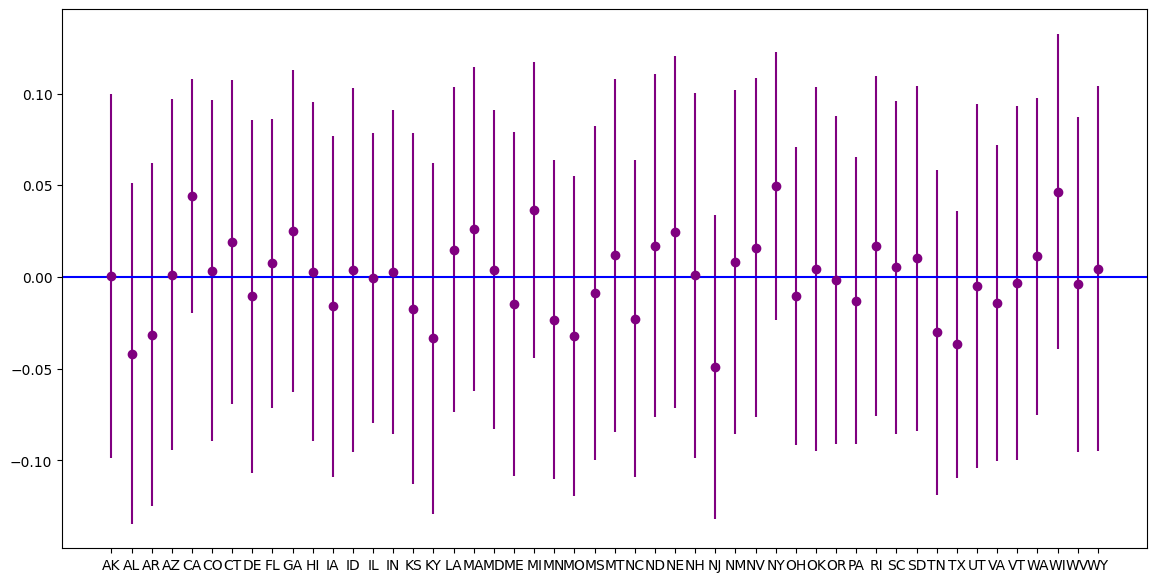

In [ ]:
plt.figure(figsize=(14, 7))

plt.errorbar(df_random_m5.State, df_random_m5.BLUP_slope, yerr=stats.norm.ppf(0.975)*df_random_m5.BLUP_slope_SE,
             color ='purple', fmt='o')

plt.axhline(y=0, color ='b', linestyle = '-')

Соответственно, нам не нужна и переменная взаимодействия между предикторами первого и второго уровней (cross-level interaction).

Однако для того, чтобы Вы понимали на будущее, как такую модель оценить при необходимости, давайте оценим для практики. Если бы нам нужно было снизить долю необъясненной дисперсии (различия во взаимосвязи партийной принадлежности и голосования в поддержку табачной индустрии, если бы они были в нашем массиве), нужно было бы включить в модель переменную взаимодействия между предиктором на первом уровне (партийной принадлежностью) и предиктором второго уровня (площадью табачных плантаций)

In [ ]:
m6 = smf.mixedlm("votepct ~ money_log*party + acres_log*party", re_formula = 'party', groups="state", data=mixed).fit(reml = False, method = 'lbfgs')
print(m6.summary())

                  Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       votepct 
No. Observations:         524           Method:                   ML      
No. Groups:               50            Scale:                    0.0257  
Min. group size:          2             Log-Likelihood:           188.2560
Max. group size:          55            Converged:                Yes     
Mean group size:          10.5                                            
--------------------------------------------------------------------------
                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                        0.105    0.022  4.718 0.000  0.061  0.149
party[T.Republican]              0.562    0.027 20.774 0.000  0.509  0.615
money_log                        0.088    0.009  9.646 0.000  0.070  0.106
money_log:party[T.Republican]   -0.049    0.

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [ ]:
m6.pvalues.round(5)

,0
Intercept,0.00000
party[T.Republican],0.00000
money_log,0.00000
money_log:party[T.Republican],0.00003
acres_log,0.02525
acres_log:party[T.Republican],0.48682
state Var,0.02546
state x party[T.Republican] Cov,0.30792
party[T.Republican] Var,0.34342


Сделайте выводы по результатам анализа. Так ли нужны были модели со смешанными эффектами авторам исследования? Какие альтернативы можно было рассмотреть?